# Building a Minimal Graph RAG System

In this tutorial we’ll build the smallest useful Graph RAG pipeline you can run in a single notebook. No databases required! We’ll build a graph from wikipedia pages and answer questions using the retrieved graph facts. We'll use [LlamaIndex](https://www.llamaindex.ai/) — a framework designed to connect LLMs with external data.

**Why Graph RAG?** Vanilla RAG retrieves chunks by similarity and hopes the model “connects the dots” in the prompt.
Graph RAG makes these connections explicit by turning text into relations and then retrieving along graph paths.

## Why graph RAG?

Let us remind a typical RAG pipeline:

<center>
  <img src="https://dist.neo4j.com/wp-content/uploads/20240227120536/rag-process.png"
       width="640" alt="RAG concepts">
  <div><small><a href="https://neo4j.com/blog/genai/what-is-graphrag/">Source</a></small></div>

**Why vector-only RAG is often insufficient?** *Consider a user asking about a specific product feature.*

- A standard vector RAG may retrieve chunks that mention the product name, but miss crucial sections elsewhere (e.g., caveats, version differences, or configuration steps) that together form the correct answer.

- Since vector similarity is not transparent, it’s hard to understand why particular chunks were returned or how they connect. Even with source citations, the retrieval rationale remains unclear.

**GraphRAG** improves retrieval by using a knowledge graph. Knowledge graph is a set of entities and their relationships. This helps:

- Follow the right connections in the graph to collect all the pieces needed from different parts of the docs.

- Be more accurate by focusing only on facts that are clearly linked to the question.

- Be explainable by showing the path in the graph (which sources and relationships) that led to the answer.

<center>
  <img src="https://api.weekly.vn/files/1/public/1742982227576_53644254-f92c-46e6-8555-cd4ea7fa135a"
       width="640" alt="RAG concepts">
  <div><small><a href="https://rabiloo.com/blog/graph-rag-the-upgrade-that-traditional-rag-needed">Source</a></small></div>

Now, let us start building our small pipeline. In this notebook, we will use [**LlamaIndex**](https://www.llamaindex.ai/). LlamaIndex is a framework designed to connect LLMs with external data. It provides tools for loading, structuring, and querying documents through indexes such as vector stores, knowledge graphs, and keyword tables. With LlamaIndex, you can easily build retrieval-augmented generation (RAG) pipelines, perform semantic or graph-based queries, and integrate custom data sources to enable context-aware reasoning for your LLM applications.

## Install dependencies and configure LlamaIndex to use Azure OpenAI

In [ ]:
%pip install -U \
  "llama-index" \
  "llama-index-llms-openai" \
  "llama-index-llms-azure-openai" \
  "llama-index-embeddings-azure-openai" \
  "llama-index-embeddings-huggingface>=0.2.0" \
  "llama-index-readers-wikipedia>=0.4.0" \
  wikipedia \
  networkx \
  matplotlib

<p align="center">
  <img src="https://i.ibb.co/nsJTYh6j/LLM-azure-text-clean.png" width="650">
  <br>
  <em>LLM request flow via Azure API</em>
</p>

In this step, we set up LlamaIndex to call the LLM through Azure OpenAI’s API and use a Hugging Face model for text vectorization. The LLM isn’t invoked yet — only configured.

In [ ]:
from llama_index.core import Settings, StorageContext
from llama_index.llms.azure_openai import AzureOpenAI
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
import os

azure_key = YOUR_AZURE_KEY
azure_endpoint = YOUR_AZURE_ENDPOINT

AZURE_OPENAI_API_KEY = os.environ.get("AZURE_OPENAI_API_KEY", azure_key)
AZURE_OPENAI_ENDPOINT = os.environ.get("AZURE_OPENAI_ENDPOINT", azure_endpoint)
AZURE_OPENAI_API_VERSION = os.environ.get("AZURE_OPENAI_API_VERSION", "2024-05-01-preview")
AZURE_OPENAI_DEPLOYMENT = os.getenv("DEPLOYMENT_NAME", "gpt-35-turbo")

Settings.llm = AzureOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_version=AZURE_OPENAI_API_VERSION,
    deployment_name=AZURE_OPENAI_DEPLOYMENT,
    temperature=0,
)

Settings.embed_model = HuggingFaceEmbedding(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Let's check everything is set up:

In [ ]:
try:
    # completion: prompt -> answer
    out = Settings.llm.complete("Hello from Azure!")
    print(str(out)[:120], "...")
except Exception as e:
    print("LLM call failed:", e)

Hello! How can I assist you today? ...


## Work with Wikipedia

As an information sourse, we'll use the Wikipedia pages. Let us do all the imports needed to work with the Wikipedia page information:

In [ ]:
import wikipedia  # Provides a Python interface to the Wikipedia/MediaWiki API.

# `Document` represents a single piece of source text plus optional metadata
from llama_index.core import Document

To find the correct name of Wikipedia page with certain information, one can do:

In [ ]:
print(wikipedia.search("Artificial intelligence"))

['Artificial intelligence', 'Artificial general intelligence', 'History of artificial intelligence', 'Generative artificial intelligence', 'A.I. Artificial Intelligence', 'Applications of artificial intelligence', 'Association for the Advancement of Artificial Intelligence', 'Existential risk from artificial intelligence', 'Ethics of artificial intelligence', 'Hallucination (artificial intelligence)']


Now, let's download several wikipedia pages about AI:

In [ ]:
def load_wiki(topic: str) -> Document:
    hits = wikipedia.search(topic)
    if not hits:
        raise ValueError(f"No wiki hits for: {topic}")
    title = hits[0]
    page = wikipedia.page(title, auto_suggest=False, redirect=True)
    return Document(text=page.content)

docs = [
    load_wiki("Artificial intelligence"),
    load_wiki("Machine learning"),
    load_wiki("Deep learning"),
    load_wiki("Transformer (machine learning model)"),
    load_wiki("Generative artificial intelligence"),
    load_wiki("AI ethics"),
]

print("Docs loaded:", len(docs), "chars:", [len(d.text) for d in docs])

Docs loaded: 6 chars: [89961, 59716, 56382, 109423, 39624, 62432]


## Build a Knowledge graph

Now, let's build a **Knowledge Graph** from our documents. A knowledge graph represents our data in a convenient graph form, showing how different entities are connected. Below, we’ll take a look at how the data is structured so that it can be stored as a graph. Let’s start creating the graph — since the dataset is quite large, the process might take a while (around 5 minutes)!

In [ ]:
from llama_index.core import KnowledgeGraphIndex, StorageContext
from llama_index.core.storage.docstore import SimpleDocumentStore
from llama_index.core.graph_stores import SimpleGraphStore

# StorageContext keeps together
# - the raw documents/nodes (docstore)
# - the extracted knowledge graph triples (graph_store)
storage_context = StorageContext.from_defaults(
    docstore=SimpleDocumentStore(),   # holds original documents / parsed nodes
    graph_store=SimpleGraphStore(),   # holds (subject, predicate, object) triplets
)

# Create the Knowledge Graph index from the loaded documents.
# Under the hood:
# 1) documents are split into chunks (“nodes”);
# 2) each node is processed to extract semantic triplets (S–P–O);
# 3) triplets are written into the graph_store.
index = KnowledgeGraphIndex.from_documents(
    docs,                             # list of input documents
    storage_context=storage_context,  # target stores for docs and graph
    max_triplets_per_chunk=40,        # cap on extracted triplets per chunk
    show_progress=True                # display tqdm progress
)

Parsing nodes:   0%|          | 0/6 [00:00<?, ?it/s]

Processing nodes:   0%|          | 0/101 [00:00<?, ?it/s]

## How to structure the information? — Triples!

Information is usually structured like shown in the diagram:

<center>
  <img src="https://cdn-images-1.medium.com/v2/resize:fit:1024/0*15bC3jsppjnHnaEE"
       width="640" alt="RAG concepts">
  <div><small><a href="https://neo4j.com/blog/developer/graphrag-field-guide-rag-patterns/">Source</a></small></div>

Data is represented as **triples** — facts of the form ```(subject, predicate, object)```. Each arrow becomes a triple that we can store and query, e.g., (Document, HAS_CHAPTER, Chapter 2), (Chapter 2, HAS_SECTION, Section B), (Chunk b1, PART_OF, Section B). It gives us a consistent way to encode hierarchy and containment: e.g., Document → Chapter → Section → Subsection → Chunk.

In RAG, the triples let us jump to the right chunks and move up the hierarchy for context, so retrieval is accurate, transparent, and easy to grow.

Together, these triples compose the knowledge graph built from our data.

## Plot the Knowledge Graph

We've already built a knowledge graph ```index```, and now we want to plot it. More precisely, we'll have a plot of triples extracted from our data!

Each triple ```(subject, predicate, object)``` becomes a **directed edge** from subject to object, and the edge is labeled with the predicate. We use ```NetworkX``` — a Python library for creating, analyzing, and visualizing graphs.

We can get a NetworkX graph directly from our Knowledge graph:

In [ ]:
import networkx as nx

# Build a NetworkX view of our Knowledge Graph index (`index` was created earlier from the docs)
G_nx = index.get_networkx_graph(limit=150)  # limit = 150 means taking only 150 nodes; default is 100

Let's have a look at the triples:

In [ ]:
# Extract triples as (subject, predicate, object) from edge attributes
raw_triples = [(u, d.get("label", ""), v) for u, v, d in G_nx.edges(data=True)]

raw_triples

[('Artificial intelligence', 'Is', 'Capability'),
 ('Artificial intelligence', 'Bring about', 'Human extinction'),
 ('Ai', 'Perform', 'Tasks'),
 ('Ai', 'Is', 'Field'),
 ('Ai', 'Draws upon', 'Psychology'),
 ('Ai', 'Draws upon', 'Linguistics'),
 ('Ai', 'Draws upon', 'Philosophy'),
 ('Ai', 'Draws upon', 'Neuroscience'),
 ('Ai', 'Was founded as', 'Academic discipline'),
 ('Ai', 'Solve', 'Problems'),
 ('Ai', 'Used', 'Military operations'),
 ('Ai', 'Used', 'Investigate patterns'),
 ('Ai', 'Used', 'Historical data'),
 ('Ai', 'Used', 'Provide information'),
 ('Ai', 'Used', 'Evacuation conditions'),
 ('Ai', 'Helped', 'Farmers'),
 ('Ai', 'Increase', 'Yield'),
 ('Ai', 'Identify', 'Areas'),
 ('Ai', 'Predict', 'Ripening time'),
 ('Ai', 'Monitor', 'Soil moisture'),
 ('Ai', 'Operate', 'Agricultural robots'),
 ('Ai', 'Conduct', 'Predictive analytics'),
 ('Ai', 'Classify', 'Livestock pig call emotions'),
 ('Ai', 'Automate', 'Greenhouses'),
 ('Ai', 'Detect', 'Diseases'),
 ('Ai', 'Detect', 'Pests'),
 ('A

## Plot the Knowledge Graph

We can plot a Knowledge graph. Here, we are going to plot only the subgraph:

/tmp/ipython-input-641663504.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


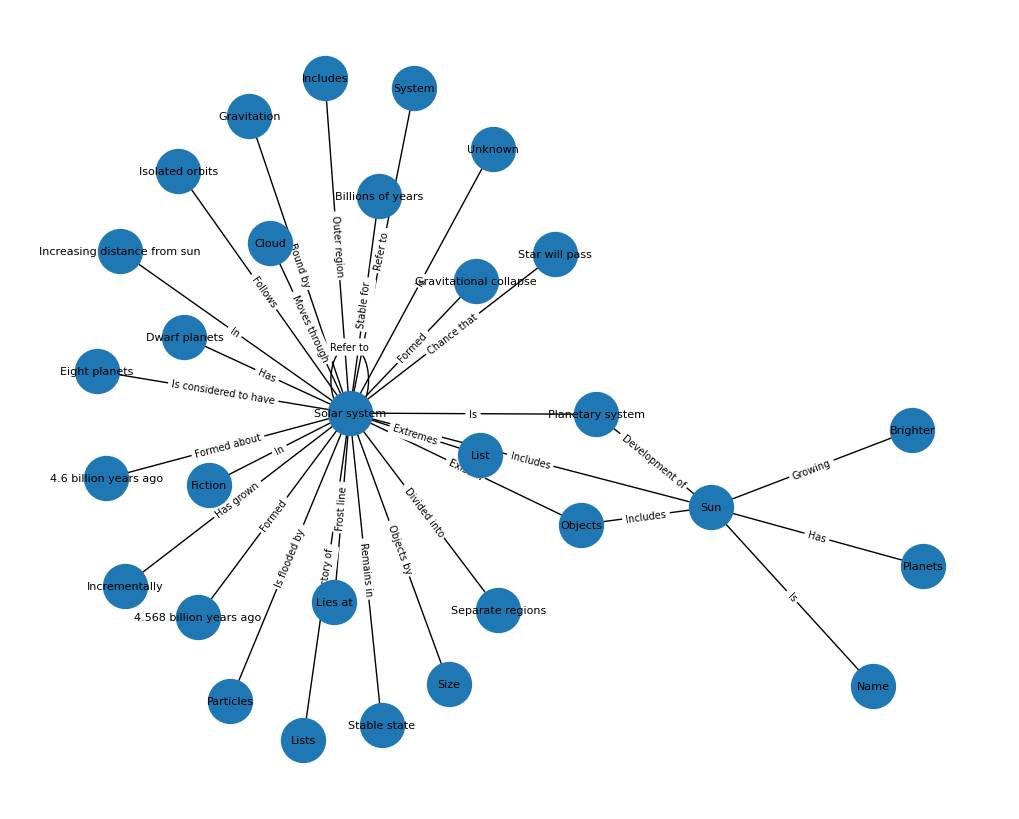

In [ ]:
import matplotlib.pyplot as plt

def draw_kg(G, max_nodes=30):
    """
    Draw a subgraph of G.
    """
    nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:max_nodes]]
    H = G.subgraph(nodes).copy()

    pos = nx.spring_layout(H, seed=42)  # calculate the nodes coordinates
    plt.figure(figsize=(10, 8))
    nx.draw(H, pos, with_labels=True, node_size=1000, font_size=8, arrows=True)

    edge_labels = {(u, v): d.get("label", "") for u, v, d in H.edges(data=True)}
    nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=7)

    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_kg(G_nx)

It’s also possible to reconstruct a graph from the extracted triples and visualize it. Here, we’ll get a clearer picture since we’re using only the first few triples without shuffling — they belong to the same topic.

/tmp/ipython-input-1773658131.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis("off"); plt.tight_layout(); plt.show()


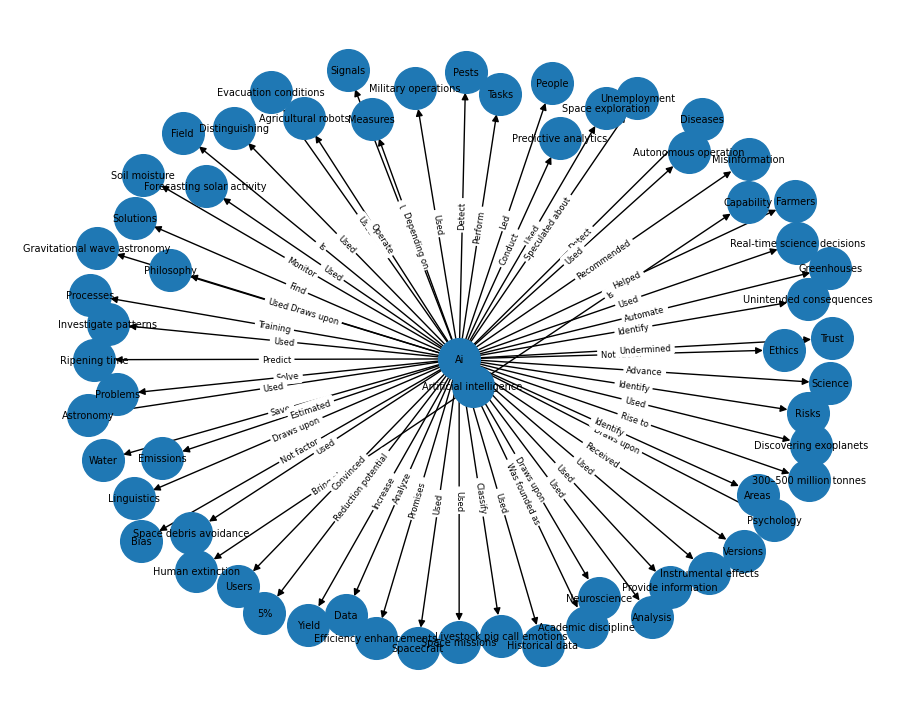

In [ ]:
def draw_kg_triples(triples, limit=60):
    T = triples[:limit]  # how many triples we want to show

    # build a graph
    G = nx.DiGraph()
    for s, p, o in T:
        G.add_edge(s, o, label=p)

    # plotting
    pos = nx.spring_layout(G, seed=42)  # calculate the nodes coordinates
    plt.figure(figsize=(9,7))
    nx.draw(G, pos, with_labels=True, node_size=900, font_size=7, arrows=True)
    edge_labels = {(u,v): d["label"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.axis("off"); plt.tight_layout(); plt.show()

draw_kg_triples(raw_triples, limit=60)

## Ask questions!

Now, we have the knowlegde graph ```index```, and we want to ask questions based on the data we processed! We are going to ask the following question:

>How is Geoffrey Hinton connected to Transformers?

Geoffrey Hinton is a pioneer of deep learning whose research on neural networks laid the foundations that later enabled the development of Transformer architectures.

*We expect classic RAG to fail* because the relevant information is spread across different documents — one about Hinton and another about Transformer models. And *Graph RAG to find the correct answer* after linking the concepts through relationships like

>Geoffrey Hinton → pioneered → Deep Learning → inspired → Transformer architecture.

### Query Graph RAG

Firstly, let's check the Graph RAG. We can prompt in a very simple way:

In [ ]:
qe_kw = index.as_query_engine(
    retriever_mode="keyword",
    verbose=True,  # print the retrieval info
    response_mode="tree_summarize",
)

query = "How is Geoffrey Hinton connected to Transformers?"
response = qe_kw.query(query)
print(response)

Extracted keywords: ['Geoffrey', 'Transformers', 'Geoffrey Hinton', 'Hinton', 'connected']
KG context:
The following are knowledge sequence in max depth 2 in the form of directed graph like:
`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`
['Transformers', 'Have', 'Advantage']
['Transformers', 'Led to', 'Development']
['Transformers', 'Have been applied in', 'Modalities beyond text']
['Transformers', 'Analyse', 'Input data']
['Transformers', 'May use', 'Positional encoding methods']
['Transformers', 'Is', 'Library']
['Transformers', 'Supplies', 'Architectures']
['Architectures', 'Have been applied to', 'Computer vision']
['Architectures', 'Have been applied to', 'Speech recognition']
['Architectures', 'Have been applied to', 'Natural language processing']
['Architectures', 'Have been applied to', 'Machine translation']
['Architectures', 'Have been applied to', 'Bioinformatics']
['Architectures', 'Have been applied to', 'Drug design']
['Architectures', 'Hav

We've got the correct answer. But what is more interesting, we see the **KG context** — triples that were used to return the answer! We can also see the chunks associated with these triples:


In [ ]:
for i, sn in enumerate(response.source_nodes, 1):
    print(f"[{i}] score={getattr(sn, 'score', None)}")
    n = sn.node
    print("node_id:", n.node_id)
    print("metadata:", n.metadata)

    text = n.get_content()
    print(text)

[1] score=1000.0
node_id: 456763c2-9949-4283-9024-a3a7002b0438
metadata: {}
==== Relative Position Encodings ====
Relative Position Encodings is similar to ALiBi, but more generic:
  
    
      
        
          
            
              
                
                  Attention
                
                (
                Q
                ,
                K
                ,
                V
                )
                =
                
                  softmax
                
                
                  (
                  
                    
                      
                        
                          Q
                          
                            K
                            
                              
                                T
                              
                            
                          
                        
                        
                          
                      

As we can see, the text chunks associated with the triples talk about deep learning. Using its general knowledge (who Geoffrey Hinton is) together with our provided context, the model produces a correct answer.

Now, let's try not to use the text chunk, i.e., use only connections.

In [ ]:
qe_kw = index.as_query_engine(
    retriever_mode="keyword",
    verbose=False,  # don't print the retrieval info
    response_mode="tree_summarize",
    include_text=False  # don't use related chunks
)

query = "How is Geoffrey Hinton connected to Transformers?"
response = qe_kw.query(query)
print(response)

Geoffrey Hinton is connected to Transformers through the application of Transformers in various fields such as computer vision, speech recognition, natural language processing, machine translation, bioinformatics, drug design, medical image analysis, climate science, material inspection, and board game programs.


Notice that the answer has changed: previously, it was more precise (“Transformers are part of deep learning; Geoffrey Hinton pioneered deep learning”), whereas now the model links Hinton to transformers via their applications, which we do see reflected in the extracted triples.

### Usual RAG isn't enough

Now, let us check that usual RAG doesn't do well. In LlamaIndex, we need just three lines to build and query the RAG system:

In [ ]:
from llama_index.core import VectorStoreIndex

rag_index = VectorStoreIndex.from_documents(docs)
rag_engine = rag_index.as_query_engine(similarity_top_k=3)

print(rag_engine.query(query))

Geoffrey Hinton is not directly mentioned in the provided context information.


## Exercise

You want to make a Graph RAG system about Space & Astronomy. For it, several Wikipedia pages may be useful: Solar System, Planet, Moon, Space exploration, and NASA. Do the following steps (note that we've done them all already when building the RAG system about AI!):

(1) Extract corresponding Wikipedia pages. You might want to start with a search for "Space exploration".

(2) Build a Knowledge graph and plot it.

(3) Ask questions.

You can use the following questions:

- What is the structure of the Solar System, and how are the planets classified?

- How do planets differ from moons in their formation and orbits?

- What are the key components of the Solar System beyond the planets?

- How does the Moon influence Earth’s environment and tides?

## Solution

First, let's find the Wikipedia pages we need:

In [ ]:
print(wikipedia.search("Space exploration"))

['Space exploration', 'SpaceX', 'Timeline of space exploration', 'NASA', 'Future of space exploration', 'Exploration', 'Deep space exploration', 'Benefits of space exploration', 'Rover (space exploration)', 'Outline of space exploration']


In [ ]:
docs = [
    load_wiki("Solar system"),
    load_wiki("Planet"),
    load_wiki("Moon"),
    load_wiki("Space exploration"),
    load_wiki("NASA"),
]

print("Docs loaded:", len(docs), "chars:", [len(d.text) for d in docs])

Docs loaded: 5 chars: [59746, 70468, 87683, 43569, 86910]


In [ ]:
# StorageContext keeps together
# - the raw documents/nodes (docstore)
# - the extracted knowledge graph triples (graph_store)
storage_context = StorageContext.from_defaults(
    docstore=SimpleDocumentStore(),   # holds original documents / parsed nodes
    graph_store=SimpleGraphStore(),   # holds (subject, predicate, object) triplets
)

# Create the Knowledge Graph index from the loaded documents.
# Under the hood:
# 1) documents are split into chunks (“nodes”);
# 2) each node is processed to extract semantic triplets (S–P–O);
# 3) triplets are written into the graph_store.
index = KnowledgeGraphIndex.from_documents(
    docs,                             # list of input documents
    storage_context=storage_context,  # target stores for docs and graph
    max_triplets_per_chunk=40,        # cap on extracted triplets per chunk
    show_progress=True                # display tqdm progress
)

Parsing nodes:   0%|          | 0/5 [00:00<?, ?it/s]

Processing nodes:   0%|          | 0/96 [00:00<?, ?it/s]

/tmp/ipython-input-641663504.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


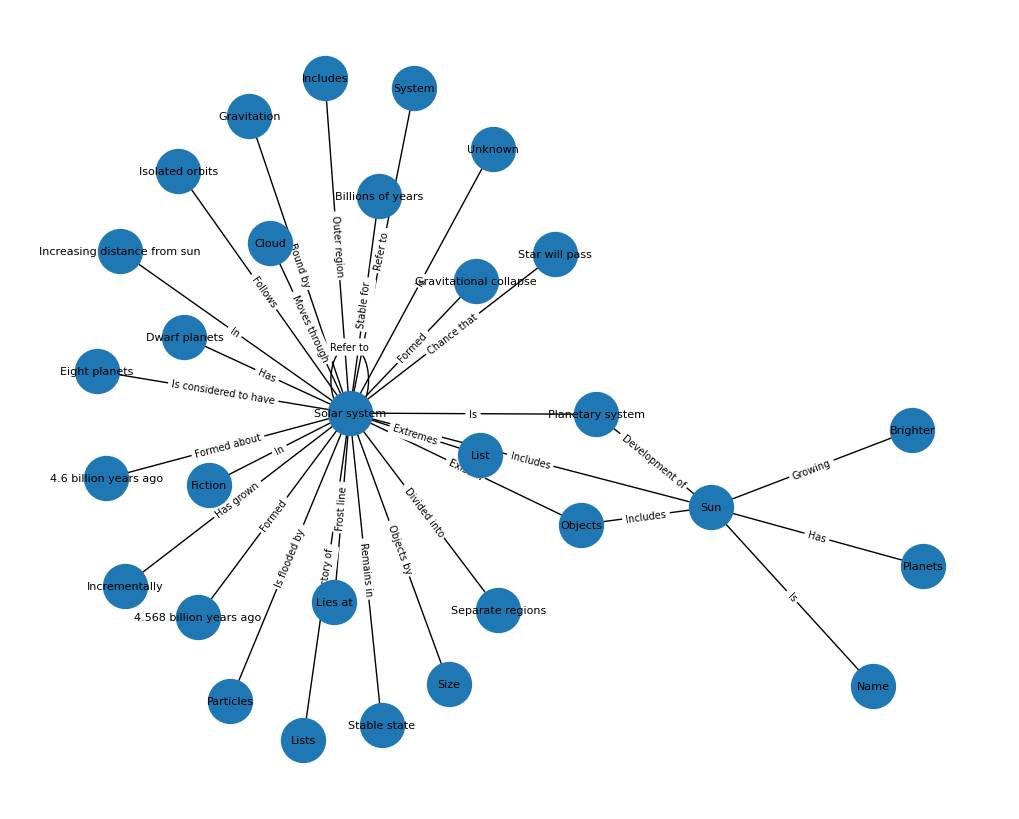

In [ ]:
G_nx = index.get_networkx_graph()
draw_kg(G_nx)

In [ ]:
qe_kw = index.as_query_engine(
    retriever_mode="keyword",
    verbose=True,  # print the retrieval info
    response_mode="tree_summarize",
)

query = "What is the structure of the Solar System and how are the planets classified?"
response = qe_kw.query(query)
print(response)

Extracted keywords: ['Solar System', 'classified', 'System', 'Solar', 'planets', 'structure']
KG context:
The following are knowledge sequence in max depth 2 in the form of directed graph like:
`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`
['System', 'Incorporates', 'Planets']
['Planets', 'Are', 'Eight']
['Planets', 'Are', 'Most massive objects']
['Planets', 'Are', 'Terrestrial']
['Planets', 'Are', 'Inner solar system']
['Planets', 'Orbit within', 'Zone']
['Planets', 'Are', 'Gas giants']
['Planets', 'Are', 'Ice giants']
['Planets', 'Possess', 'Mass']
['Planets', 'Have', 'Satellites']
['Planets', 'Formed by', 'Accretion']
['Planets', 'Formed', 'Dust and gas']
['Planets', 'Formed', 'Larger bodies']
['Planets', 'Formed', 'Rocky']
['Planets', 'Lie near', 'Invariable plane']
['Planets', 'Have', 'Secondary systems']
['Planets', 'Being orbited by', 'Moons']
['Planets', 'Orbit the sun in', 'Same direction']
['Planets', 'Account for', 'Most of the rest of the an